# Dataset 3 — Exploratory Analysis & Cleaning

**Goal:** Produce three clean output files from the raw dataset3:
- `dataset3_cleaned.csv` — valid measurement rows ready for analysis
- `dataset3_removed.csv` — rows removed with documented reason
- `dataset3_derived_quantities.csv` — Finnish derived quantities set aside separately

**Pipeline:**
1. Load raw data
2. Parse result and uncertainty columns
3. Clean nuclide names (canonical mapping, categorisation)
4. Standardise units
5. Exploratory analysis (distributions, outliers, MDA, sample structure)
6. Apply STUK-confirmed removals
7. Export outputs

---
## Step 1 — Load Raw Data

In [1]:
import pandas as pd

# Load both files
d3_clean = pd.read_csv("dataset3_cleaned.csv")
d3_removed = pd.read_csv("dataset3_removed.csv")

# Merge row-wise
merged_dataset3_clean = pd.concat(
    [d3_clean, d3_removed],
    ignore_index=True
)

# Optional sort by pseudoid
merged_dataset3_clean = merged_dataset3_clean.sort_values(
    by="pseudoid"
).reset_index(drop=True)

# Save
merged_dataset3_clean.to_csv(
    "merged_dataset3_clean.csv",
    index=False
)

print("Merged shape:", merged_dataset3_clean.shape)

Merged shape: (98096, 11)


---
## Step 7 — Export Output Files

Three files are produced:
- **`dataset3_cleaned.csv`** — valid measurement rows + kept derived quantities (Kokonaisalfa, Kokonaisbeeta, Sr stab etc.)
- **`dataset3_removed.csv`** — all removed rows with documented reason (includes Viitteellinen annos and Sr saalis)
- **`dataset3_derived_quantities.csv`** — derived quantities that were kept, as a reference file

**Why Viitteellinen annos and Sr saalis are removed:**
- `Viitteellinen annos` = indicative dose in mSv — a calculated dose estimate, not a raw measurement
- `Sr saalis` = strontium yield/recovery — a radiochemical process efficiency monitor, not a sample measurement

All other derived quantities (Kokonaisalfa, Kokonaisbeeta, Sr stab, Uraani etc.) are kept in the
cleaned dataset as they may be useful context, but are distinguishable from nuclide measurements
via the `nuclide_clean` column value.

In [2]:
import pandas as pd

d3 = pd.read_csv("dataset3_cleaned.csv")

print(d3.shape)
print(d3.columns.tolist())
print(d3.head())

(97957, 10)
['pseudoid', 'nuclide', 'nuclide_clean', 'result_raw', 'result', 'unit_std', 'uncertainty', 'is_mda', 'is_mass_concentration', 'is_pu239_240']
   pseudoid nuclide nuclide_clean          result_raw       result  unit_std  \
0     50001    K-40          K-40  1121.5664549703706  1121.566455  Bq/kg_kp   
1     50001  PB-210        PB-210   88.54319706216569    88.543197  Bq/kg_kp   
2     50001  BI-214        BI-214   50.78390397259847    50.783904  Bq/kg_kp   
3     50001  PB-214        PB-214   51.06821236564313    51.068212  Bq/kg_kp   
4     50001  CS-137        CS-137   0.409496306079783     0.409496  Bq/kg_kp   

   uncertainty  is_mda  is_mass_concentration  is_pu239_240  
0          4.1   False                  False         False  
1         14.0   False                  False         False  
2          5.1   False                  False         False  
3          5.0   False                  False         False  
4         19.0   False                  False         

## Step 1. Load the cleaned dataset

In [3]:
import pandas as pd

d3 = pd.read_csv("merged_dataset3_clean.csv")

print(d3.shape)
print(d3.columns.tolist())
d3.head()

(98096, 11)
['pseudoid', 'nuclide', 'nuclide_clean', 'result_raw', 'result', 'unit_std', 'uncertainty', 'is_mda', 'is_mass_concentration', 'is_pu239_240', 'removal_reason']


,pseudoid,nuclide,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda,is_mass_concentration,is_pu239_240,removal_reason
0,50001,K-40,K-40,1121.5664549703706,1121.566455,Bq/kg_kp,4.1,False,False,False,NaN
1,50001,PB-210,PB-210,88.54319706216569,88.543197,Bq/kg_kp,14.0,False,False,False,NaN
2,50001,BI-214,BI-214,50.78390397259847,50.783904,Bq/kg_kp,5.1,False,False,False,NaN
3,50001,PB-214,PB-214,51.06821236564313,51.068212,Bq/kg_kp,5.0,False,False,False,NaN
4,50001,CS-137,CS-137,0.409496306079783,0.409496,Bq/kg_kp,19.0,False,False,False,NaN


## Step 2. Create the first modeling subset

In [4]:
d3_model = d3[
    (~d3["is_mass_concentration"]) &
    (~d3["is_pu239_240"])
].copy()

print(d3_model.shape)
print("Unique samples:", d3_model["pseudoid"].nunique())
print("Unique nuclides:", d3_model["nuclide_clean"].nunique())

(97471, 11)
Unique samples: 23083
Unique nuclides: 366


Why we do this

We first build a simple and stable version for modeling.
We remove special measurement types because they are not the same kind of signal as normal radioactivity activity values.

Why we did not keep them now

is_mass_concentration and is_pu239_240 are useful, but they make the first model harder to interpret.
It is better to start with the core measurement rows, then later test whether adding those special rows improves results.

## Step 3. Convert long format into sample level wide format

In [5]:
d3_wide = d3_model.pivot_table(
    index="pseudoid",
    columns="nuclide_clean",
    values="result",
    aggfunc="mean"
).fillna(0)

d3_wide.reset_index(inplace=True)

print(d3_wide.shape)
d3_wide.head()

(23081, 366)


nuclide_clean,pseudoid,AC-220,AC-225,AC-227,AC-228,AC-231,AG-101,AG-106M,AG-108,AG-108M,...,YB-169,YB-175,YB-177,ZN-65,ZN-69M,ZN-74,ZR-104,ZR-89,ZR-95,ZR-97
0,50001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,50003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,50004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Why we do this

Clustering and autoencoder need one row per sample.
Right now the cleaned data has many rows per sample, so we pivot it to wide format.

What this is

Now each row is one pseudoid, and each nuclide becomes a column.
Missing nuclides are filled with 0, meaning no measured value for that sample in this modeling table.

## Step 4. Remove very rare nuclide columns

In [6]:
threshold = int(0.01 * len(d3_wide))

non_zero_counts = (d3_wide.drop(columns="pseudoid") != 0).sum()

keep_cols = non_zero_counts[non_zero_counts > threshold].index

d3_wide = d3_wide[["pseudoid"] + list(keep_cols)]

print(d3_wide.shape)

(23081, 46)


Why we do this

Some nuclides appear in only a very small number of samples.
Those extremely rare columns add noise and make clustering less stable.

Why we use 1%

This is a simple filtering rule to keep only features that appear often enough to matter.
We do not want the model to focus on columns that are almost always zero.

## Step 5. Separate ID and features

In [7]:
X = d3_wide.drop(columns=["pseudoid"])

print(X.shape)
X.head()

(23081, 45)


nuclide_clean,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,CO-58,...,Sr-90,TE-123M,TH-228,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95
0,0.0,0.0,0.0,0.0,0.0,0.0,50.783904,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.025147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,3.090339,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Why we do this

pseudoid is just an identifier.
It should never be used as a feature in clustering or anomaly detection.

What this is

X is now the actual feature matrix that the model will learn from.

## Step 6. Scale the data

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(23081, 45)


Why we do this

Different nuclides can have very different numeric ranges.
Scaling makes the features comparable, so large magnitude columns do not dominate the model unfairly.

Why we did not skip scaling

Autoencoders and clustering work much better when the data is on a similar scale.
Without scaling, the model may mostly learn the biggest-value nuclides only.

In [9]:
print(d3_wide.shape)
print(X.shape)

(23081, 46)
(23081, 45)


## Step 7. Train Autoencoder

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

inp = Input(shape=(input_dim,))

x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
latent = Dense(10, activation="relu")(x)

x = Dense(32, activation="relu")(latent)
x = Dense(64, activation="relu")(x)
out = Dense(input_dim)(x)

autoencoder = Model(inp, out)
encoder = Model(inp, latent)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(X_scaled, X_scaled, epochs=30, batch_size=256)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/Users/mdmahfuzurrahman/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step - loss: 1.0241 
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - loss: 0.9714
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - loss: 1.2726
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - loss: 0.8780
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.8320
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 0.6515
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 0.5682
Epoch 8/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 0.4726
Epoch 9/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - loss: 0.4011
Epoch 10/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 0.6164
Epoch 11/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 0.6063
Epoch 12/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - loss: 0.4969
Epoch 13/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 0.5886
Epoch 14/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 0.4034
Epoch 15/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - l

🔸 Why we do this

We use an autoencoder to learn a compressed version of the data.

It tries to reconstruct the input
If data is normal → easy to reconstruct
If data is unusual → hard to reconstruct
🔸 What this gives us

Two things:

Latent features (compressed representation)
Reconstruction ability (for anomaly detection later)
🔸 Why we did not use raw features for clustering

Because:

45 features can still be noisy
autoencoder learns hidden structure
clustering works better on this compressed space

## Step 8. Get latent representation

In [11]:
latent_features = encoder.predict(X_scaled)

print(latent_features.shape)

722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step
(23081, 10)


In [12]:
print(latent_features.shape)

(23081, 10)


## Step 9. Autoencoder Clustering

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(latent_features)

d3_wide["cluster"] = clusters

🔸 Why we do this

We cluster on the latent space, not raw features.

latent features capture hidden structure
reduces noise
improves clustering quality
🔸 Why 6 clusters

Because:

same approach as Dataset 1
keeps consistency in your report
allows comparison

## Step 10. Cluster distribution

In [14]:
print(d3_wide["cluster"].value_counts())

cluster
0    22998
4       34
2       21
5       20
3        5
1        3
Name: count, dtype: int64


🔸 Why we do this

This tells us:

how many samples per cluster
whether clusters are balanced
if any cluster is very small (possible anomaly group)

## Step 11. Silhouette score

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(latent_features, clusters)
print("Silhouette score:", score)

Silhouette score: 0.9763133


🔸 Why we do this

This measures how well separated the clusters are

close to 1 → very good separation
around 0.5 → good
near 0 → overlapping clusters

## Step 12. Visualization

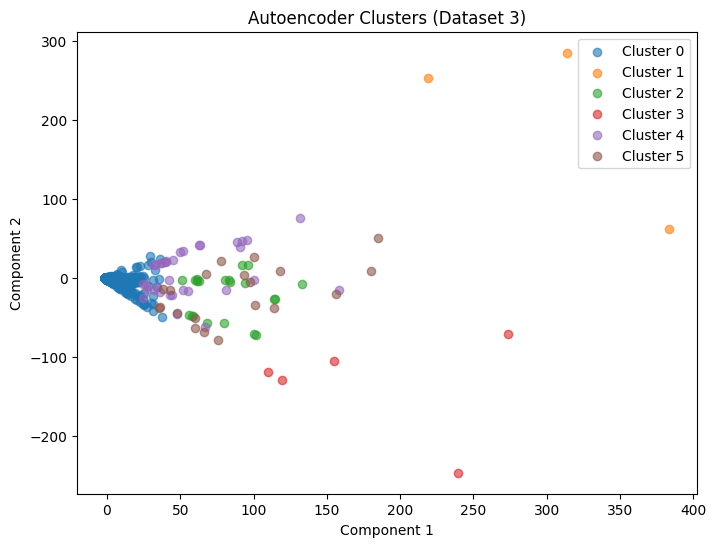

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(latent_features)

plt.figure(figsize=(8,6))

for c in sorted(d3_wide["cluster"].unique()):
    idx = d3_wide["cluster"] == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.6)

plt.legend()
plt.title("Autoencoder Clusters (Dataset 3)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [17]:
print(d3_wide["cluster"].value_counts())
print("Silhouette:", score)

cluster
0    22998
4       34
2       21
5       20
3        5
1        3
Name: count, dtype: int64
Silhouette: 0.9763133


Step 10.1 Load Dataset 0

In [18]:
d0 = pd.read_csv("dataset0.txt")

print(d0.shape)
print(d0.columns.tolist())
d0.head()

(30710, 1)
['+----------+------------------+-------------+-------------+----------------+']


,+----------+------------------+-------------+-------------+----------------+
0,| pseudoid | pretreatmenttype | sampleclass | ...
1,+----------+------------------+-------------+-...
2,| 51055 | RAW | C-1 | ...
3,| 52642 | RAW | C-1 | ...
4,| 60026 | RAW | C-1 | ...


In [19]:
import pandas as pd

with open("dataset0.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

table_lines = [line.strip() for line in lines if line.strip().startswith("|")]

rows = []
for line in table_lines:
    parts = [x.strip() for x in line.strip("|").split("|")]
    rows.append(parts)

df0 = pd.DataFrame(rows[1:], columns=rows[0])
df0.columns = [c.strip().lower() for c in df0.columns]

df0["pseudoid"] = pd.to_numeric(df0["pseudoid"], errors="coerce").astype("Int64")
df0_small = df0[["pseudoid", "sampleclass"]].copy()

print(df0_small.shape)
display(df0_small.head())

(30707, 2)


,pseudoid,sampleclass
0,51055,C-1
1,52642,C-1
2,60026,C-1
3,61469,C-1
4,77085,C-2


In [20]:
df0_small

,pseudoid,sampleclass
0,51055,C-1
1,52642,C-1
2,60026,C-1
3,61469,C-1
4,77085,C-2
...,...,...
30702,50724,C-20
30703,62115,C-1
30704,77495,C-1
30705,59089,C-1


## Step 10.2 Ensure matching ID type

In [21]:
d3_wide["pseudoid"] = pd.to_numeric(d3_wide["pseudoid"], errors="coerce").astype("Int64")

## Step 10.3 Merge clustering result with labels

In [22]:
merged = d3_wide.merge(
    df0_small,
    on="pseudoid",
    how="left"
)

print(merged.shape)
print("Missing sampleclass:", merged["sampleclass"].isna().sum())

(23081, 48)
Missing sampleclass: 0


## Step 10.4 Crosstab (main validation table)

In [23]:
ct = pd.crosstab(merged["cluster"], merged["sampleclass"])
print(ct)

sampleclass  C-0   C-1  C-10  C-11  C-12  C-13  C-14  C-15  C-16  C-17  ...  \
cluster                                                                 ...   
0              2  6011  1119    93    47   166   151    56    13     8  ...   
1              0     1     0     0     0     0     0     0     0     0  ...   
2              0     0     0     0     0     0     1     0     0     0  ...   
3              0     0     0     0     0     0     0     0     0     0  ...   
4              0     3     0     0     0     0     0     0     0     0  ...   
5              0     0     0     0     0     0     0     0     0     0  ...   

sampleclass  C-38  C-39   C-4  C-40  C-41  C-5  C-6  C-8  C-9  NULL  
cluster                                                              
0             429   230  3729  1237    37  436  117  163  226     2  
1               0     0     0     0     0    0    0    0    0     0  
2               0     0    11     0     0    4    0    1    0     0  
3               2

## Step 10.5 Heatmap visualization

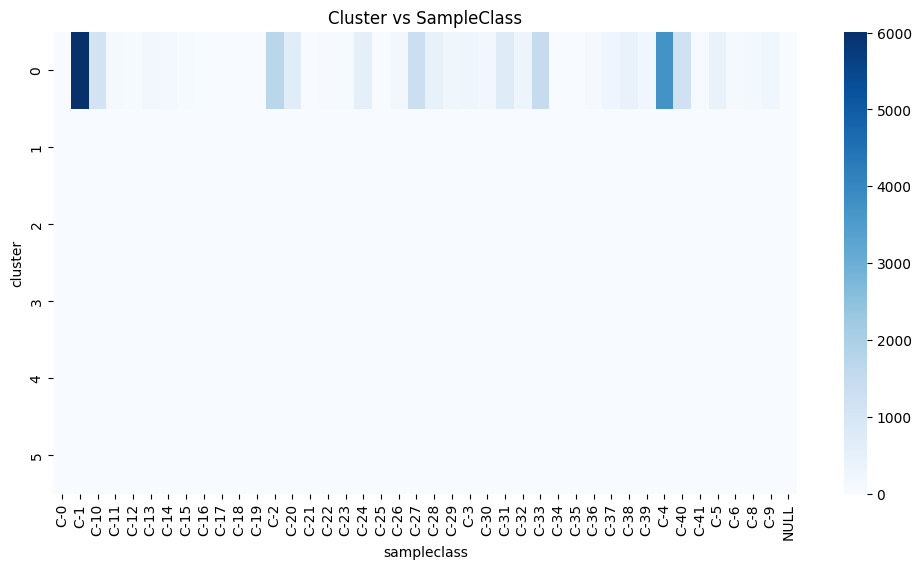

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap="Blues")
plt.title("Cluster vs SampleClass")
plt.show()

In [25]:
valid = merged.dropna(subset=["sampleclass"]).copy()

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(valid["sampleclass"], valid["cluster"])
nmi = normalized_mutual_info_score(valid["sampleclass"], valid["cluster"])

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.0009043660136262662
NMI: 0.005298511606715735


In [26]:
print(ct)
print("ARI:", ari)
print("NMI:", nmi)

sampleclass  C-0   C-1  C-10  C-11  C-12  C-13  C-14  C-15  C-16  C-17  ...  \
cluster                                                                 ...   
0              2  6011  1119    93    47   166   151    56    13     8  ...   
1              0     1     0     0     0     0     0     0     0     0  ...   
2              0     0     0     0     0     0     1     0     0     0  ...   
3              0     0     0     0     0     0     0     0     0     0  ...   
4              0     3     0     0     0     0     0     0     0     0  ...   
5              0     0     0     0     0     0     0     0     0     0  ...   

sampleclass  C-38  C-39   C-4  C-40  C-41  C-5  C-6  C-8  C-9  NULL  
cluster                                                              
0             429   230  3729  1237    37  436  117  163  226     2  
1               0     0     0     0     0    0    0    0    0     0  
2               0     0    11     0     0    4    0    1    0     0  
3               2

## Step 11: Anomaly Detection (MAIN RESULT)

In [27]:
import numpy as np

recon = autoencoder.predict(X_scaled)
mse = np.mean((X_scaled - recon)**2, axis=1)

threshold = np.percentile(mse, 95)

d3_wide["reconstruction_error"] = mse
d3_wide["anomaly"] = (mse > threshold).astype(int)

722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step


In [28]:
d3_wide.sort_values("reconstruction_error", ascending=False).head(10)

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
4974,56633,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,351.679514,1
6613,58812,0.000000,9.640736,0.0,0.000000,12817.192542,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,4,306.776898,1
11895,65789,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,299.234040,1
5451,57278,3530.113220,-160.286747,0.0,0.000000,0.000000,6.195974e+03,511654.693604,0.0,0.000000,...,0.000000,1.778463e+03,0.0,0.000000e+00,0.0,0.0,0.0,4,245.991876,1
10052,63341,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,223399.554137,0.000000e+00,0.0,1.111026e+04,0.0,0.0,0.0,5,230.562035,1
21251,78283,154298.418651,0.000000,0.0,0.000000,0.000000,1.444153e+05,51716.158291,0.0,0.000000,...,0.000000,4.345652e+04,0.0,0.000000e+00,0.0,0.0,0.0,5,202.277191,1
13471,67878,0.000002,0.000000,0.0,0.000000,0.001357,5.776400e+17,0.000397,0.0,0.000000,...,0.000005,1.507071e+17,0.0,2.929838e-07,0.0,0.0,0.0,1,146.945393,1
4810,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,296.002974,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,139.302346,1
20677,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,3,105.931768,1
6547,58732,0.000000,0.000000,0.0,121.204811,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,104.234502,1


In [29]:
## Anomaly Detection using Autoencoder

In [30]:
### Step 11.1 Reconstruct the data

In [31]:
recon = autoencoder.predict(X_scaled)

722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 213us/step


## Step 11.2 Compute reconstruction error

In [32]:
import numpy as np

mse = np.mean((X_scaled - recon)**2, axis=1)

## Step 11.3 Set anomaly threshold

In [33]:
threshold = np.percentile(mse, 95)
print("Threshold:", threshold)

Threshold: 0.02463892732792792


### Step 11.4 Label anomalies

In [34]:
d3_wide["reconstruction_error"] = mse
d3_wide["anomaly"] = (mse > threshold).astype(int)

Step 11.5 Check how many anomalies

In [35]:
print(d3_wide["anomaly"].value_counts())

anomaly
0    21927
1     1154
Name: count, dtype: int64


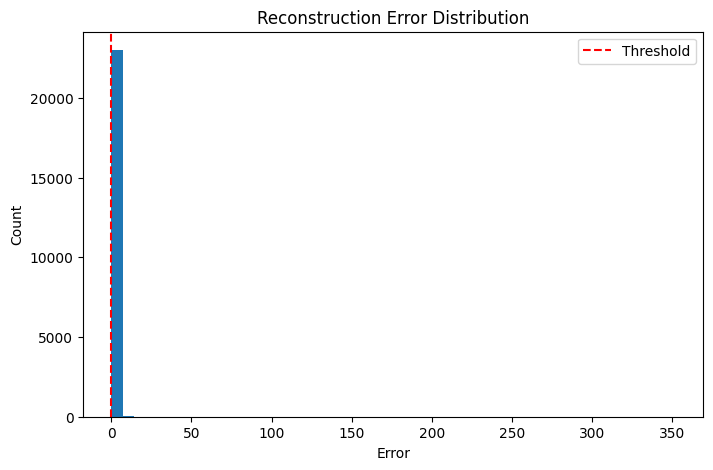

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(mse, bins=50)
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.legend()
plt.show()

Step 11.7 See top anomalies

In [37]:
top_anomalies = d3_wide.sort_values("reconstruction_error", ascending=False).head(10)

display(top_anomalies)

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
4974,56633,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,351.679514,1
6613,58812,0.000000,9.640736,0.0,0.000000,12817.192542,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,4,306.776898,1
11895,65789,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,299.234040,1
5451,57278,3530.113220,-160.286747,0.0,0.000000,0.000000,6.195974e+03,511654.693604,0.0,0.000000,...,0.000000,1.778463e+03,0.0,0.000000e+00,0.0,0.0,0.0,4,245.991876,1
10052,63341,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,223399.554137,0.000000e+00,0.0,1.111026e+04,0.0,0.0,0.0,5,230.562035,1
21251,78283,154298.418651,0.000000,0.0,0.000000,0.000000,1.444153e+05,51716.158291,0.0,0.000000,...,0.000000,4.345652e+04,0.0,0.000000e+00,0.0,0.0,0.0,5,202.277191,1
13471,67878,0.000002,0.000000,0.0,0.000000,0.001357,5.776400e+17,0.000397,0.0,0.000000,...,0.000005,1.507071e+17,0.0,2.929838e-07,0.0,0.0,0.0,1,146.945393,1
4810,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,296.002974,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,139.302346,1
20677,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,3,105.931768,1
6547,58732,0.000000,0.000000,0.0,121.204811,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,104.234502,1


In [38]:
print(d3_wide["anomaly"].value_counts())
print(threshold)
display(top_anomalies)

anomaly
0    21927
1     1154
Name: count, dtype: int64
0.02463892732792792


nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
4974,56633,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,351.679514,1
6613,58812,0.000000,9.640736,0.0,0.000000,12817.192542,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,4,306.776898,1
11895,65789,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,299.234040,1
5451,57278,3530.113220,-160.286747,0.0,0.000000,0.000000,6.195974e+03,511654.693604,0.0,0.000000,...,0.000000,1.778463e+03,0.0,0.000000e+00,0.0,0.0,0.0,4,245.991876,1
10052,63341,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,223399.554137,0.000000e+00,0.0,1.111026e+04,0.0,0.0,0.0,5,230.562035,1
21251,78283,154298.418651,0.000000,0.0,0.000000,0.000000,1.444153e+05,51716.158291,0.0,0.000000,...,0.000000,4.345652e+04,0.0,0.000000e+00,0.0,0.0,0.0,5,202.277191,1
13471,67878,0.000002,0.000000,0.0,0.000000,0.001357,5.776400e+17,0.000397,0.0,0.000000,...,0.000005,1.507071e+17,0.0,2.929838e-07,0.0,0.0,0.0,1,146.945393,1
4810,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,296.002974,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,139.302346,1
20677,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,3,105.931768,1
6547,58732,0.000000,0.000000,0.0,121.204811,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,104.234502,1


In [39]:
top_anomalies = d3_wide.sort_values("reconstruction_error", ascending=False).head(10)

display(top_anomalies)

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
4974,56633,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,351.679514,1
6613,58812,0.000000,9.640736,0.0,0.000000,12817.192542,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,4,306.776898,1
11895,65789,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,299.234040,1
5451,57278,3530.113220,-160.286747,0.0,0.000000,0.000000,6.195974e+03,511654.693604,0.0,0.000000,...,0.000000,1.778463e+03,0.0,0.000000e+00,0.0,0.0,0.0,4,245.991876,1
10052,63341,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,223399.554137,0.000000e+00,0.0,1.111026e+04,0.0,0.0,0.0,5,230.562035,1
21251,78283,154298.418651,0.000000,0.0,0.000000,0.000000,1.444153e+05,51716.158291,0.0,0.000000,...,0.000000,4.345652e+04,0.0,0.000000e+00,0.0,0.0,0.0,5,202.277191,1
13471,67878,0.000002,0.000000,0.0,0.000000,0.001357,5.776400e+17,0.000397,0.0,0.000000,...,0.000005,1.507071e+17,0.0,2.929838e-07,0.0,0.0,0.0,1,146.945393,1
4810,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,296.002974,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,139.302346,1
20677,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,3,105.931768,1
6547,58732,0.000000,0.000000,0.0,121.204811,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,104.234502,1


In [40]:
import pandas as pd
import numpy as np

percentiles = list(range(90, 101))

threshold_table = pd.DataFrame({
    "percentile": percentiles,
    "threshold": [np.percentile(mse, p) for p in percentiles],
    "num_anomalies": [(mse > np.percentile(mse, p)).sum() for p in percentiles],
})

threshold_table["percent_anomalies"] = (
    threshold_table["num_anomalies"] / len(mse) * 100
)

display(threshold_table)

,percentile,threshold,num_anomalies,percent_anomalies
0,90,0.007832,2308,9.999567
1,91,0.009406,2078,9.003076
2,92,0.011745,1847,8.002253
3,93,0.014594,1616,7.001430
4,94,0.018832,1385,6.000607
5,95,0.024639,1154,4.999783
6,96,0.037136,924,4.003293
7,97,0.055849,693,3.002470
8,98,0.105789,462,2.001646
9,99,0.390372,227,0.983493


In [41]:
threshold_table["gap"] = threshold_table["threshold"].diff()

display(threshold_table)

,percentile,threshold,num_anomalies,percent_anomalies,gap
0,90,0.007832,2308,9.999567,NaN
1,91,0.009406,2078,9.003076,0.001574
2,92,0.011745,1847,8.002253,0.002339
3,93,0.014594,1616,7.001430,0.002849
4,94,0.018832,1385,6.000607,0.004237
5,95,0.024639,1154,4.999783,0.005807
6,96,0.037136,924,4.003293,0.012497
7,97,0.055849,693,3.002470,0.018713
8,98,0.105789,462,2.001646,0.049940
9,99,0.390372,227,0.983493,0.284583


## Threshold 99 

In [42]:
threshold_99 = np.percentile(mse, 99)

print("Threshold (99%):", threshold_99)

Threshold (99%): 0.3903716117551966


In [43]:
d3_wide["anomaly_99"] = (mse > threshold_99).astype(int)

print(d3_wide["anomaly_99"].value_counts())

anomaly_99
0    22854
1      227
Name: count, dtype: int64


In [44]:
top_anomalies_99 = d3_wide[d3_wide["anomaly_99"] == 1] \
    .sort_values("reconstruction_error", ascending=False)

display(top_anomalies_99.head(10))

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly,anomaly_99
4974,56633,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,351.679514,1,1
6613,58812,0.000000,9.640736,0.0,0.000000,12817.192542,0.000000e+00,0.000000,0.0,0.000000,...,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,4,306.776898,1,1
11895,65789,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,5,299.234040,1,1
5451,57278,3530.113220,-160.286747,0.0,0.000000,0.000000,6.195974e+03,511654.693604,0.0,0.000000,...,1.778463e+03,0.0,0.000000e+00,0.0,0.0,0.0,4,245.991876,1,1
10052,63341,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000e+00,0.0,1.111026e+04,0.0,0.0,0.0,5,230.562035,1,1
21251,78283,154298.418651,0.000000,0.0,0.000000,0.000000,1.444153e+05,51716.158291,0.0,0.000000,...,4.345652e+04,0.0,0.000000e+00,0.0,0.0,0.0,5,202.277191,1,1
13471,67878,0.000002,0.000000,0.0,0.000000,0.001357,5.776400e+17,0.000397,0.0,0.000000,...,1.507071e+17,0.0,2.929838e-07,0.0,0.0,0.0,1,146.945393,1,1
4810,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,296.002974,...,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,139.302346,1,1
20677,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,3,105.931768,1,1
6547,58732,0.000000,0.000000,0.0,121.204811,0.000000,0.000000e+00,0.000000,0.0,0.000000,...,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2,104.234502,1,1


In [45]:
threshold_99 = np.percentile(mse, 99)

d3_wide["reconstruction_error"] = mse
d3_wide["anomaly_99"] = (mse > threshold_99).astype(int)

anomaly_ids_99 = d3_wide.loc[d3_wide["anomaly_99"] == 1, "pseudoid"]

print("Number of 99% anomalies:", len(anomaly_ids_99))
display(anomaly_ids_99.head(10))

Number of 99% anomalies: 227


27     50040
141    50191
262    50347
308    50405
455    50591
466    50606
594    50787
632    50837
652    50859
705    50927
Name: pseudoid, dtype: Int64

In [46]:
d3_model_rows = d3_model.copy()
d3_model_rows = d3_model_rows.reset_index().rename(columns={"index": "d3_row_number"})

In [47]:
anomaly_rows_99 = d3_model_rows[d3_model_rows["pseudoid"].isin(anomaly_ids_99)].copy()

print("Number of Dataset 3 rows belonging to 99% anomaly pseudoids:", len(anomaly_rows_99))

display(
    anomaly_rows_99[
        ["d3_row_number", "pseudoid", "nuclide_clean", "result_raw", "result", "unit_std", "uncertainty", "is_mda"]
    ].head(50)
)

Number of Dataset 3 rows belonging to 99% anomaly pseudoids: 2345


,d3_row_number,pseudoid,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda
99,103,50040,SB-124,5.650301105862477,5.650301e+00,Bq/m3,11.0,False
100,104,50040,NB-95,<2.432848357988944,2.432848e+00,Bq/m3,NaN,True
101,105,50040,MN-54,5.308912236267827,5.308912e+00,Bq/m3,11.0,False
102,106,50040,TE-123M,<1.4589973151756446,1.458997e+00,Bq/m3,NaN,True
103,107,50040,ZR-95,<3.5396949893811085,3.539695e+00,Bq/m3,NaN,True
104,108,50040,RH-106,<12.999749020666178,1.299975e+01,Bq/m3,NaN,True
105,109,50040,CO-58,6.7666325345226515,6.766633e+00,Bq/m3,11.0,False
106,110,50040,CS-134,14.903089887321519,1.490309e+01,Bq/m3,4.4,False
107,111,50040,AG-110M,218.25780796949903,2.182578e+02,Bq/m3,1.7,False
108,112,50040,CO-60,252.23566117750136,2.522357e+02,Bq/m3,3.4,False


In [48]:
anomaly_rows_99 = d3_model_rows[d3_model_rows["pseudoid"].isin(anomaly_ids_99)].copy()

print("Number of Dataset 3 rows belonging to 99% anomaly pseudoids:", len(anomaly_rows_99))

display(
    anomaly_rows_99[
        ["d3_row_number", "pseudoid", "nuclide_clean", "result_raw", "result", "unit_std", "uncertainty", "is_mda"]
    ]
)

Number of Dataset 3 rows belonging to 99% anomaly pseudoids: 2345


,d3_row_number,pseudoid,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda
99,103,50040,SB-124,5.650301105862477,5.650301,Bq/m3,11.0,False
100,104,50040,NB-95,<2.432848357988944,2.432848,Bq/m3,NaN,True
101,105,50040,MN-54,5.308912236267827,5.308912,Bq/m3,11.0,False
102,106,50040,TE-123M,<1.4589973151756446,1.458997,Bq/m3,NaN,True
103,107,50040,ZR-95,<3.5396949893811085,3.539695,Bq/m3,NaN,True
...,...,...,...,...,...,...,...,...
97458,98083,80704,CR-51,9381.858602252836,9381.858602,Bq/l,4.3,False
97459,98084,80704,CD-109,10807.004931298488,10807.004931,Bq/l,7.0,False
97460,98085,80704,PB-210,11789.897157140304,11789.897157,Bq/l,4.4,False
97461,98086,80704,CS-137,1882.5662251551748,1882.566225,Bq/l,3.6,False


In [49]:
print("Anomalous samples:", len(anomaly_ids_99))
print("Rows belonging to those samples:", len(anomaly_rows_99))

Anomalous samples: 227
Rows belonging to those samples: 2345


Step 12.1 Create interpretable features

In [50]:
res_cols = [c for c in d3_wide.columns 
            if c not in ["pseudoid", "cluster", "reconstruction_error", "anomaly_99"]]

d3_wide["total_activity"] = d3_wide[res_cols].sum(axis=1)
d3_wide["num_nuclides"] = (d3_wide[res_cols] > 0).sum(axis=1)
d3_wide["max_activity"] = d3_wide[res_cols].max(axis=1)

Step 12.2 Compare normal vs anomalies

In [51]:
d3_wide.groupby("anomaly_99")[["total_activity", "num_nuclides", "max_activity"]].mean()

nuclide_clean,total_activity,num_nuclides,max_activity
anomaly_99,,,
0,3.902597e+49,4.033561,3.902597e+49
1,1.917845e+53,8.533040,1.917845e+53


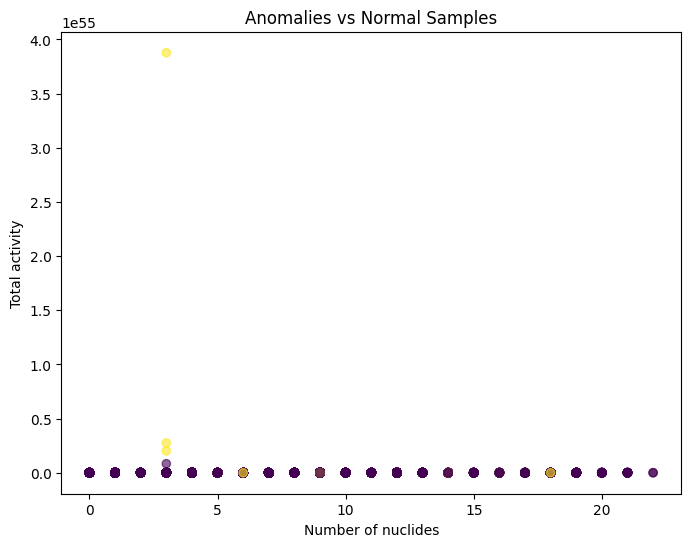

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    d3_wide["num_nuclides"],
    d3_wide["total_activity"],
    c=d3_wide["anomaly_99"],
    alpha=0.6
)

plt.xlabel("Number of nuclides")
plt.ylabel("Total activity")
plt.title("Anomalies vs Normal Samples")

plt.show()

In [53]:
t90 = np.percentile(mse, 90)
t99 = np.percentile(mse, 99)

def classify(x):
    if x <= t90:
        return "Typical"
    elif x <= t99:
        return "Atypical"
    else:
        return "Erroneous"

d3_wide["final_class"] = [classify(x) for x in mse]

In [54]:
print(d3_wide["final_class"].value_counts())

final_class
Typical      20773
Atypical      2081
Erroneous      227
Name: count, dtype: int64


In [55]:
final_output = d3_wide[[
    "pseudoid",
    "final_class",
    "reconstruction_error",
    "total_activity",
    "num_nuclides",
    "max_activity"
]]

display(final_output.head())

nuclide_clean,pseudoid,final_class,reconstruction_error,total_activity,num_nuclides,max_activity
0,50001,Typical,0.004560,1312.371265,5,1121.566455
1,50002,Typical,0.002548,0.104467,2,0.079320
2,50003,Typical,0.000422,115.446577,2,106.960499
3,50004,Typical,0.000232,3.115184,3,3.090339
4,50005,Typical,0.000229,0.000041,1,0.000041


In [56]:
print("=== Clustering Results ===")
print(d3_wide["cluster"].value_counts())

from sklearn.metrics import silhouette_score
print("\nSilhouette Score:", silhouette_score(latent_features, d3_wide["cluster"]))

=== Clustering Results ===
cluster
0    22998
4       34
2       21
5       20
3        5
1        3
Name: count, dtype: int64

Silhouette Score: 0.9763133


In [57]:
print("\n=== Validation Results ===")

print("\nCluster vs SampleClass:")
print(ct)

print("\nARI:", ari)
print("NMI:", nmi)


=== Validation Results ===

Cluster vs SampleClass:
sampleclass  C-0   C-1  C-10  C-11  C-12  C-13  C-14  C-15  C-16  C-17  ...  \
cluster                                                                 ...   
0              2  6011  1119    93    47   166   151    56    13     8  ...   
1              0     1     0     0     0     0     0     0     0     0  ...   
2              0     0     0     0     0     0     1     0     0     0  ...   
3              0     0     0     0     0     0     0     0     0     0  ...   
4              0     3     0     0     0     0     0     0     0     0  ...   
5              0     0     0     0     0     0     0     0     0     0  ...   

sampleclass  C-38  C-39   C-4  C-40  C-41  C-5  C-6  C-8  C-9  NULL  
cluster                                                              
0             429   230  3729  1237    37  436  117  163  226     2  
1               0     0     0     0     0    0    0    0    0     0  
2               0     0    11     

In [58]:
print("\n=== Threshold Analysis ===")
display(threshold_table)


=== Threshold Analysis ===


,percentile,threshold,num_anomalies,percent_anomalies,gap
0,90,0.007832,2308,9.999567,NaN
1,91,0.009406,2078,9.003076,0.001574
2,92,0.011745,1847,8.002253,0.002339
3,93,0.014594,1616,7.001430,0.002849
4,94,0.018832,1385,6.000607,0.004237
5,95,0.024639,1154,4.999783,0.005807
6,96,0.037136,924,4.003293,0.012497
7,97,0.055849,693,3.002470,0.018713
8,98,0.105789,462,2.001646,0.049940
9,99,0.390372,227,0.983493,0.284583


In [59]:
print("\n=== Anomaly Detection (99%) ===")

print("Threshold (99%):", threshold_99)
print(d3_wide["anomaly_99"].value_counts())


=== Anomaly Detection (99%) ===
Threshold (99%): 0.3903716117551966
anomaly_99
0    22854
1      227
Name: count, dtype: int64


In [60]:
print("\n=== Final Classification ===")

print(d3_wide["final_class"].value_counts())


=== Final Classification ===
final_class
Typical      20773
Atypical      2081
Erroneous      227
Name: count, dtype: int64


In [61]:
anomaly_ids_99

27       50040
141      50191
262      50347
308      50405
455      50591
         ...  
22879    80428
23020    80624
23035    80643
23051    80670
23077    80704
Name: pseudoid, Length: 227, dtype: Int64

In [62]:
anomaly_rows_99.to_csv("dataset3_anomalies_99.csv", index=False)

In [63]:
anomaly_ids_99.to_csv("anomaly_ids_99.csv", index=False)

In [64]:
d3_wide
# with pseudoid and anomaly_99

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly,anomaly_99,total_activity,num_nuclides,max_activity,final_class
0,50001,0.0,0.0,0.0,0.0,0.0,0.0,50.783904,0.0,0.0,...,0.0,0.0,0,0.004560,0,0,1312.371265,5,1121.566455,Typical
1,50002,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.002548,0,0,0.104467,2,0.079320,Typical
2,50003,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.000422,0,0,115.446577,2,106.960499,Typical
3,50004,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.000232,0,0,3.115184,3,3.090339,Typical
4,50005,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.000229,0,0,0.000041,1,0.000041,Typical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23076,80703,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.000292,0,0,73.051016,2,72.638832,Typical
23077,80704,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,5,9.584057,1,1,17587.148704,6,11789.897157,Erroneous
23078,80705,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.028962,1,0,1018.632061,5,871.845568,Atypical
23079,80706,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0,0.003851,0,0,1063.562982,2,1063.289909,Typical


[[22806   217]
 [   48    10]]


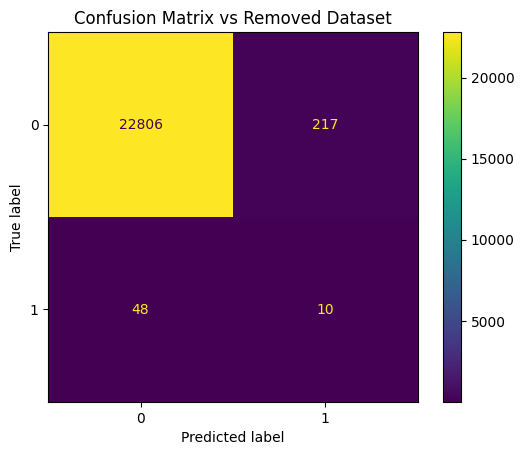

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     23023
           1       0.04      0.17      0.07        58

    accuracy                           0.99     23081
   macro avg       0.52      0.58      0.53     23081
weighted avg       1.00      0.99      0.99     23081



In [65]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load removed dataset
removed = pd.read_csv("dataset3_removed.csv")

# Get pseudoids marked as known problematic
removed_ids = set(removed["pseudoid"].dropna().unique())

# Create truth labels
eval_df = d3_wide[["pseudoid","anomaly_99"]].copy()

eval_df["true_label"] = eval_df["pseudoid"].apply(
    lambda x: 1 if x in removed_ids else 0
)

# y true vs y pred
y_true = eval_df["true_label"]
y_pred = eval_df["anomaly_99"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix vs Removed Dataset")
plt.show()

# Metrics
print(classification_report(y_true, y_pred))

In [66]:
import pandas as pd
import numpy as np

d3_clean = pd.read_csv("dataset3_cleaned.csv")
d3_removed = pd.read_csv("dataset3_removed.csv")

In [67]:
removed_ids = pd.Series(d3_removed["pseudoid"].dropna().unique(), name="pseudoid")
print("Removed pseudoids:", len(removed_ids))

Removed pseudoids: 58


In [68]:
clean_ids = pd.Series(d3_clean["pseudoid"].dropna().unique(), name="pseudoid")
clean_ids_only = clean_ids[~clean_ids.isin(removed_ids)].drop_duplicates()

print("Available clean pseudoids:", len(clean_ids_only))

Available clean pseudoids: 23104


In [69]:
normal_test_ids = clean_ids_only.sample(frac=0.20, random_state=42)

print("20% sampled clean pseudoids:", len(normal_test_ids))

20% sampled clean pseudoids: 4621


In [70]:
anomaly_test_df = pd.DataFrame({"pseudoid": removed_ids})
anomaly_test_df["true_label"] = 1

normal_test_df = pd.DataFrame({"pseudoid": normal_test_ids})
normal_test_df["true_label"] = 0

test_eval_ids = pd.concat([anomaly_test_df, normal_test_df], ignore_index=True).drop_duplicates()

print("Total evaluation pseudoids:", len(test_eval_ids))
display(test_eval_ids.head())

Total evaluation pseudoids: 4679


,pseudoid,true_label
0,50748,1
1,51098,1
2,51255,1
3,52225,1
4,52595,1


In [71]:
pred_df = d3_wide[["pseudoid", "anomaly_99"]].copy()

pred_df["pseudoid"] = pd.to_numeric(pred_df["pseudoid"], errors="coerce")
test_eval_ids["pseudoid"] = pd.to_numeric(test_eval_ids["pseudoid"], errors="coerce")

eval_df = test_eval_ids.merge(pred_df, on="pseudoid", how="left")
eval_df["anomaly_99"] = eval_df["anomaly_99"].fillna(0).astype(int)

print(eval_df.shape)
display(eval_df.head())

(4679, 3)


,pseudoid,true_label,anomaly_99
0,50748,1,0
1,51098,1,0
2,51255,1,1
3,52225,1,0
4,52595,1,1


Confusion Matrix:
[[4584   37]
 [  48   10]]


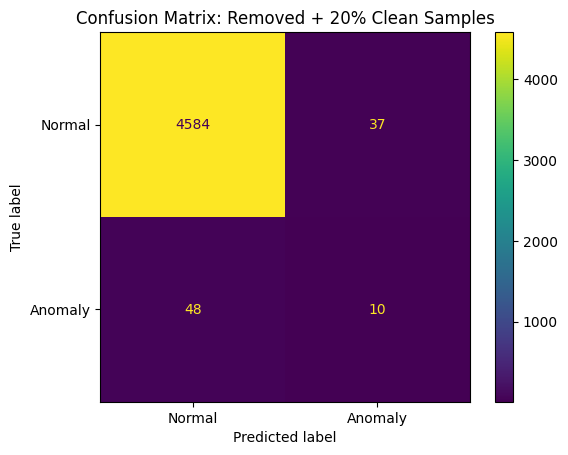


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4621
           1       0.21      0.17      0.19        58

    accuracy                           0.98      4679
   macro avg       0.60      0.58      0.59      4679
weighted avg       0.98      0.98      0.98      4679



In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_true = eval_df["true_label"]
y_pred = eval_df["anomaly_99"]

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"]).plot()
plt.title("Confusion Matrix: Removed + 20% Clean Samples")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))